In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load the data we saved in the previous notebook
df = pd.read_csv("../transaction_data.csv")
print("Data Shape:", df.shape)
display(df.head())

Data Shape: (6362620, 15)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,is_oldbalanceOrg_zero,is_newbalanceOrig_zero,is_oldbalanceDest_zero,is_newbalanceDest_zero,log_amount
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,3,0,0,1,1,9.194276
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,3,0,0,1,1,7.531166
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,4,0,1,1,1,5.204007
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,1,0,1,0,1,5.204007
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,3,0,0,1,1,9.364703


In [4]:
# Logic: Fraud transactions often have mismatched balances.

# Origin Account Balance Errors
df["balance_change_orig"] = df["newbalanceOrig"] - df["oldbalanceOrg"]
df["expected_balance_change_orig"] = df["oldbalanceOrg"] - df["amount"]
df["balance_error_orig"] = df["newbalanceOrig"] - df["expected_balance_change_orig"]

# Destination Account Balance Errors
df["balance_change_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["expected_balance_change_dest"] = df["oldbalanceDest"] + df["amount"]
df["balance_error_dest"] = df["newbalanceDest"] - df["expected_balance_change_dest"]

print("Balance Error Features Created.")

Balance Error Features Created.


In [5]:
# Amount-to-Balance Ratios
# Ratio of transaction amount to the existing balance (High ratio = Suspicious)
# Using np.where to avoid division by zero error

df["amount_to_oldbalance_orig_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    0
)

df["amount_to_oldbalance_dest_ratio"] = np.where(
    df["oldbalanceDest"] > 0,
    df["amount"] / df["oldbalanceDest"],
    0
)

print("Amount-to-Balance Ratio Features Created.")

Amount-to-Balance Ratio Features Created.


In [6]:
# Did the transaction completely empty the sender's account?
df["sender_account_emptied"] = (
    (df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)
).astype(int)

# Did the receiver get exactly the amount from zero balance?
df["dest_received_large_amount"] = (
    (df["oldbalanceDest"] == 0) & (df["newbalanceDest"] > 0)
).astype(int)

print("Account Emptying Indicators Created.")

Account Emptying Indicators Created.


In [7]:
# Flagging transactions that fall in the top 5% of all transaction amounts
large_threshold = df["amount"].quantile(0.95)
df["is_large_transaction"] = (df["amount"] > large_threshold).astype(int)

print(f"Large Transaction Threshold set at: {large_threshold:.2f}")

Large Transaction Threshold set at: 518634.20


In [8]:
# Dividing the 'step' into 6 time buckets (like different times of the day/week)
max_step = df["step"].max()
bins = np.linspace(0, max_step, 7)
df["step_bucket"] = pd.cut(df["step"], bins=bins, labels=False, include_lowest=True)

print("Time-based Step Buckets Created.")

Time-based Step Buckets Created.


In [9]:
# Count how many transactions happened in the same 'step'
step_counts = df.groupby("step").size().reset_index(name="transactions_in_step")
df = df.merge(step_counts, on="step", how="left")

# Flag if the step has higher than average traffic
median_transactions = df["transactions_in_step"].median()
df["is_high_velocity_step"] = (df["transactions_in_step"] > median_transactions).astype(int)

print("Transaction Velocity Features Created.")

Transaction Velocity Features Created.


In [10]:
# If the destination account generally holds a very high balance, it might be a merchant
median_dest_balance = df["oldbalanceDest"].median()
df["is_dest_high_balance"] = (df["oldbalanceDest"] > median_dest_balance).astype(int)

print("Merchant-like Behavior Flag Created.")

Merchant-like Behavior Flag Created.


In [11]:
# Based on EDA, TRANSFER and CASH_OUT have the highest fraud rates
type_risk = {
    "CASH_OUT": 3,
    "TRANSFER": 3,
    "CASH_IN": 1,
    "PAYMENT": 1,
    "DEBIT": 2
}

df["type_risk_score"] = df["type"].map(type_risk)

print("Transaction Type Risk Scores Applied.")

Transaction Type Risk Scores Applied.


In [12]:
# Combining multiple red flags into a single 'Suspicious Score'
df["suspicious_signal_count"] = (
    df["sender_account_emptied"] +
    df["is_large_transaction"] +
    df["dest_received_large_amount"] +
    (df["balance_error_orig"].abs() > 0).astype(int) +
    (df["balance_error_dest"].abs() > 0).astype(int) +
    (df["amount_to_oldbalance_orig_ratio"] > 1).astype(int)
)

print("Composite Suspicious Signal Count Created.")
display(df["suspicious_signal_count"].value_counts())


Composite Suspicious Signal Count Created.


suspicious_signal_count
2    2703431
1    1517706
4    1021080
3     934847
5     102779
0      78475
6       4302
Name: count, dtype: int64

In [13]:
# We already have 'type_encoded' and 'type_risk_score', so we drop the string 'type' column
df = df.drop(columns=["type"])

print("Dropped string 'type' column. Data is now fully numerical!")

Dropped string 'type' column. Data is now fully numerical!


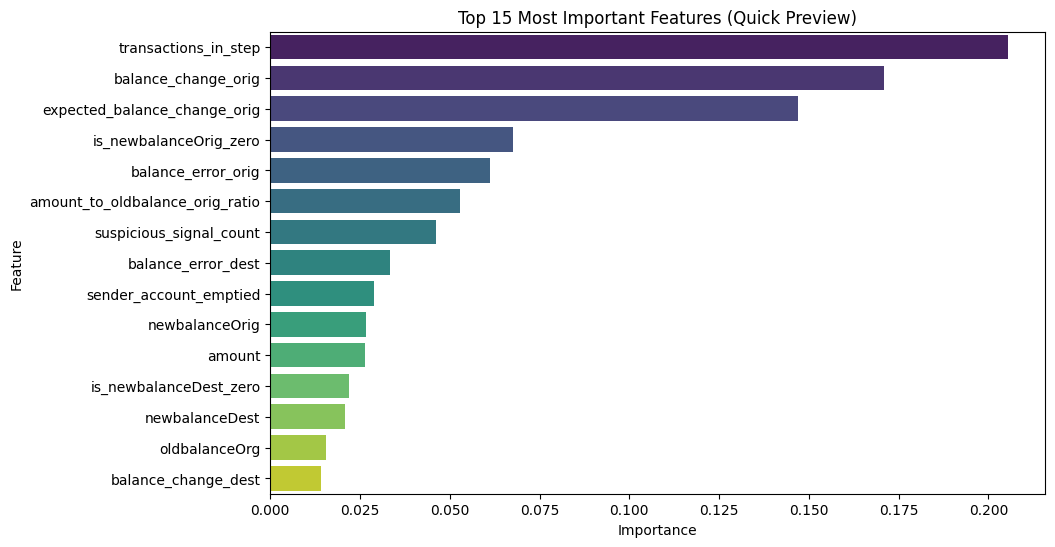

In [14]:
 # Quick Feature Importance Preview (
from sklearn.ensemble import RandomForestClassifier

# Sample data for quick training (100k rows) to avoid waiting too long
sample_df = df.sample(n=100000, random_state=42)

# Prepare X and y
X_sample = sample_df.drop(columns=["isFraud", "isFlaggedFraud"])
y_sample = sample_df["isFraud"]

# Train a quick Random Forest
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importances = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importances.head(15), palette="viridis")
plt.title("Top 15 Most Important Features (Quick Preview)")
plt.show()

### Feature Engineering Summary
successfully transformed raw data into a strong, business-logic driven dataset!
Key additions:
1. **Balance Errors**: Captured logical mismatches in sender/receiver balances.
2. **Behavioral Flags**: Flags for account emptying, zero balances, and high-value transfers.
3. **Time & Velocity**: Bucketed time steps and flagged high-traffic moments.
4. **Risk Scoring**: Assigned composite risk scores and transaction-type risk weights.

Our dataset is now highly rich and ready for robust Machine Learning models!

In [ ]:
# Save the final dataset that will be used for Model Training
final_output_path = "../transaction_data.csv"    
df.to_csv(final_output_path, index=False)

print(f"🔥 Awesome! Final Feature Engineered data saved to: {final_output_path}")
print("Final Shape:", df.shape)